<a href="https://colab.research.google.com/github/Rakshaksa/Internpe_AIML_internship/blob/main/Handwriting_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✍️ Handwritten Character Recognition
### CNN-based Digit (0–9) and Alphabet (A–Z) Recognition


## ✅ Step 1 — Check GPU

In [18]:
import tensorflow as tf
import numpy as np
import os

os.makedirs('saved_models', exist_ok=True)
os.makedirs('plots',        exist_ok=True)

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.19.0


## 📦 Step 2 — Install Dependencies

In [ ]:
!pip install tensorflow-datasets seaborn opencv-python-headless -q
print('✅ All packages installed!')

✅ All packages installed!


## ⚙️ Step 3 — Configuration

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

# Image settings
IMG_SIZE  = 28
IMG_SHAPE = (28, 28, 1)

# Number of classes
NUM_DIGIT_CLASSES    = 10
NUM_ALPHABET_CLASSES = 26

# Training hyperparameters
BATCH_SIZE    = 128
EPOCHS_DIGIT  = 15
EPOCHS_ALPHA  = 20
LEARNING_RATE = 0.001

# Label lists
DIGIT_LABELS    = [str(i) for i in range(10)]
ALPHABET_LABELS = [chr(i) for i in range(ord('A'), ord('Z') + 1)]

print('✅ Configuration done!')
print(f'   Digit classes    : {NUM_DIGIT_CLASSES}')
print(f'   Alphabet classes : {NUM_ALPHABET_CLASSES}')
print(f'   Batch size       : {BATCH_SIZE}')
print(f'   Epochs (digit)   : {EPOCHS_DIGIT}')
print(f'   Epochs (alphabet): {EPOCHS_ALPHA}')

✅ Configuration done!
   Digit classes    : 10
   Alphabet classes : 26
   Batch size       : 128
   Epochs (digit)   : 15
   Epochs (alphabet): 20


## 📂 Step 4 — Load & Preprocess Datasets

In [ ]:
# ── Shared preprocessing function ────────────────────────────
def preprocess(images, labels, num_classes):
    """Normalize to [0,1], add channel dim, one-hot encode labels."""
    images = images.astype('float32') / 255.0
    images = np.expand_dims(images, axis=-1)   # (N,28,28) → (N,28,28,1)
    labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)
    return images, labels


# ── 1. MNIST Digits ───────────────────────────────────────────
print('[1/2] Loading MNIST digit dataset...')
(x_train_d, y_train_d), (x_test_d, y_test_d) = tf.keras.datasets.mnist.load_data()
x_train_d, y_train_d = preprocess(x_train_d, y_train_d, NUM_DIGIT_CLASSES)
x_test_d,  y_test_d  = preprocess(x_test_d,  y_test_d,  NUM_DIGIT_CLASSES)
print(f'   Train : {x_train_d.shape[0]:,}  |  Test : {x_test_d.shape[0]:,}')


# ── 2. EMNIST Letters via tensorflow_datasets ─────────────────
# (Much more reliable than the 'emnist' pip package in Colab)
print('[2/2] Loading EMNIST letters via tensorflow_datasets...')
print('      First run downloads ~500 MB — please wait...')

ds_train = tfds.load('emnist/letters', split='train', as_supervised=True, shuffle_files=False)
ds_test  = tfds.load('emnist/letters', split='test',  as_supervised=True, shuffle_files=False)

def tfds_to_numpy(dataset):
    """Convert a tf.data.Dataset to numpy arrays."""
    images, labels = [], []
    for img, lbl in dataset:
        images.append(img.numpy().squeeze())   # (28,28,1) → (28,28)
        labels.append(int(lbl.numpy()))
    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int32)

print('   Extracting train samples (this takes ~1 min)...')
x_train_a_raw, y_train_a_raw = tfds_to_numpy(ds_train)

print('   Extracting test samples...')
x_test_a_raw, y_test_a_raw   = tfds_to_numpy(ds_test)

# EMNIST labels run 1–26; convert to 0–25
y_train_a_raw = y_train_a_raw - 1
y_test_a_raw  = y_test_a_raw  - 1

# Fix EMNIST orientation (known quirk: images are transposed)
x_train_a_raw = np.array([np.fliplr(np.rot90(img)) for img in x_train_a_raw])
x_test_a_raw  = np.array([np.fliplr(np.rot90(img)) for img in x_test_a_raw])

# Preprocess
x_train_a, y_train_a = preprocess(x_train_a_raw, y_train_a_raw, NUM_ALPHABET_CLASSES)
x_test_a,  y_test_a  = preprocess(x_test_a_raw,  y_test_a_raw,  NUM_ALPHABET_CLASSES)

print(f'   Train : {x_train_a.shape[0]:,}  |  Test : {x_test_a.shape[0]:,}')
print('✅ Both datasets loaded successfully!')

[1/2] Loading MNIST digit dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
   Train : 60,000  |  Test : 10,000
[2/2] Loading EMNIST letters via tensorflow_datasets...
      First run downloads ~500 MB — please wait...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.Q8BZ9Z_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.Q8BZ9Z_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
   Extracting train samples (this takes ~1 min)...
   Extracting test samples...
   Train : 88,800  |  Test : 14,800
✅ Both datasets loaded successfully!


## 🖼️ Step 5 — Visualise Sample Images

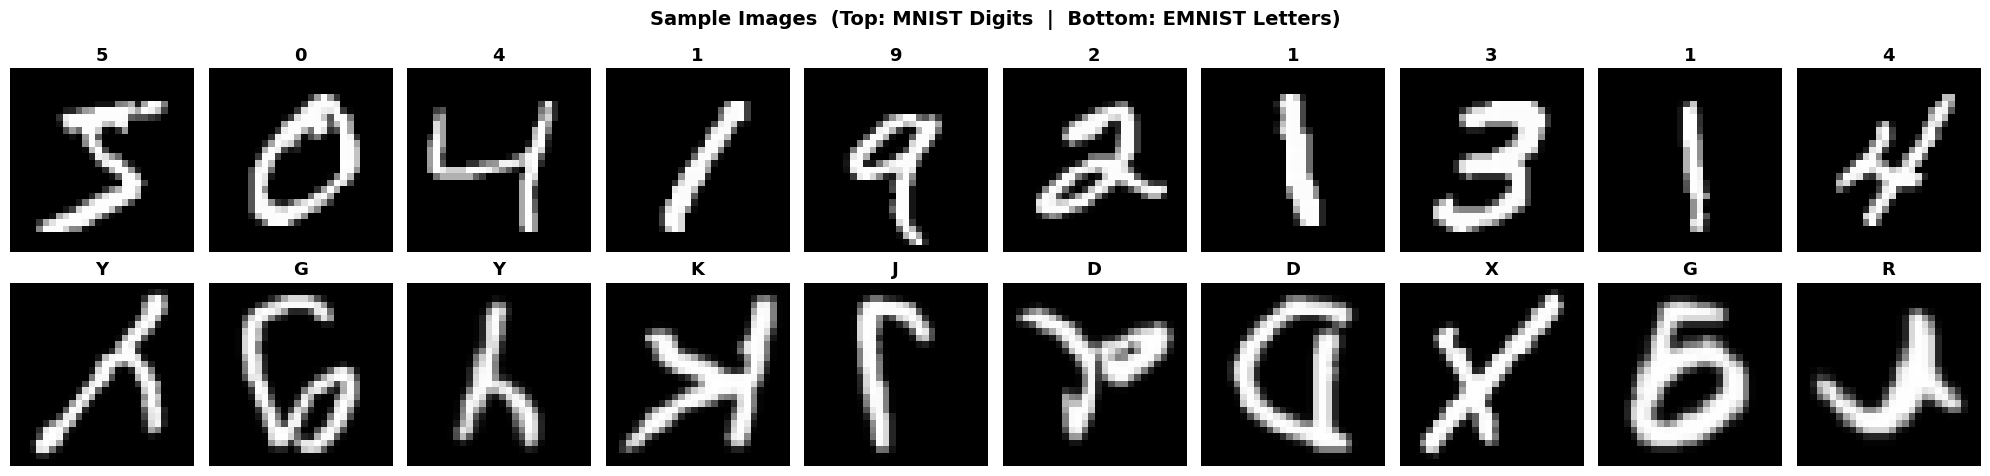

✅ Sample images displayed!


In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Sample Images  (Top: MNIST Digits  |  Bottom: EMNIST Letters)',
             fontsize=14, fontweight='bold')

for i in range(10):
    # Digit samples
    axes[0, i].imshow(x_train_d[i].squeeze(), cmap='gray')
    axes[0, i].set_title(DIGIT_LABELS[np.argmax(y_train_d[i])],
                         fontsize=13, fontweight='bold')
    axes[0, i].axis('off')

    # Alphabet samples
    axes[1, i].imshow(x_train_a[i].squeeze(), cmap='gray')
    axes[1, i].set_title(ALPHABET_LABELS[np.argmax(y_train_a[i])],
                         fontsize=13, fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('plots/sample_images.png', dpi=120)
plt.show()
print('✅ Sample images displayed!')

## 🧠 Step 6 — Build CNN Model

In [ ]:
def build_cnn(num_classes, name='CNN'):
    """
    CNN Architecture:
    ─────────────────
    Input  (28x28x1)
      Block 1 : Conv32 > Conv32 > MaxPool > Dropout(25%)
      Block 2 : Conv64 > Conv64 > MaxPool > Dropout(25%)
      Head    : Flatten > Dense(256) > Dropout(50%) > Dense(classes)
    """
    model = models.Sequential(name=name)

    # ── Convolutional Block 1 ────────────────────────────────
    model.add(layers.Input(shape=IMG_SHAPE))

    model.add(layers.Conv2D(32, (3, 3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(32, (3, 3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2, 2)))   # 28x28 → 14x14
    model.add(layers.Dropout(0.25))

    # ── Convolutional Block 2 ────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(64, (3, 3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2, 2)))   # 14x14 → 7x7
    model.add(layers.Dropout(0.25))

    # ── Fully Connected Head ─────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))

    # ── Output layer ─────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Print architecture summary
demo_model = build_cnn(10, 'SampleCNN')
demo_model.summary()
print('✅ CNN architecture defined!')

Model: "SampleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

✅ CNN architecture defined!


## 🔢 Step 7 — Train Digit Model (MNIST)

In [ ]:
# ── Data augmentation layer ───────────────────────────────────
augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')


# ── tf.data pipeline ─────────────────────────────────────────
def make_dataset(x, y, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if augment:
        ds = ds.shuffle(10000, seed=42)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(
            lambda img, lbl: (augmentation(img, training=True), lbl),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    return ds.prefetch(tf.data.AUTOTUNE)


digit_train_ds = make_dataset(x_train_d, y_train_d, augment=True)
digit_val_ds   = make_dataset(x_test_d,  y_test_d,  augment=False)


# ── Callbacks ─────────────────────────────────────────────────
digit_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'saved_models/digit_model.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
]


# ── Train ─────────────────────────────────────────────────────
print('🚀 Training Digit Model...')
digit_model   = build_cnn(NUM_DIGIT_CLASSES, 'DigitCNN')
digit_history = digit_model.fit(
    digit_train_ds,
    validation_data=digit_val_ds,
    epochs=EPOCHS_DIGIT,
    callbacks=digit_callbacks,
    verbose=1
)

loss, acc = digit_model.evaluate(digit_val_ds, verbose=0)
print(f'\n✅ Digit Model  →  Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')

🚀 Training Digit Model...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7420 - loss: 0.8786
Epoch 1: val_accuracy improved from None to 0.20270, saving model to saved_models/digit_model.keras

Epoch 1: finished saving model to saved_models/digit_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.8653 - loss: 0.4945 - val_accuracy: 0.2027 - val_loss: 3.8455 - learning_rate: 0.0010
Epoch 2/15
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9477 - loss: 0.2412
Epoch 2: val_accuracy improved from 0.20270 to 0.97790, saving model to saved_models/digit_model.keras

Epoch 2: finished saving model to saved_models/digit_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9535 - loss: 0.2243 - val_accuracy: 0.9779 - val_loss: 0.1466 - learning_rate: 0.0010
Epoch 3/15
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9612 - loss: 0.1977
Epoch 3: val_accuracy did not improve from 0.97790
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step

## 🔤 Step 8 — Train Alphabet Model (EMNIST)

In [ ]:
alpha_train_ds = make_dataset(x_train_a, y_train_a, augment=True)
alpha_val_ds   = make_dataset(x_test_a,  y_test_a,  augment=False)

alpha_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'saved_models/alphabet_model.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
]

print('🚀 Training Alphabet Model...')
alpha_model   = build_cnn(NUM_ALPHABET_CLASSES, 'AlphabetCNN')
alpha_history = alpha_model.fit(
    alpha_train_ds,
    validation_data=alpha_val_ds,
    epochs=EPOCHS_ALPHA,
    callbacks=alpha_callbacks,
    verbose=1
)

loss, acc = alpha_model.evaluate(alpha_val_ds, verbose=0)
print(f'\n✅ Alphabet Model  →  Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')

🚀 Training Alphabet Model...
Epoch 1/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5245 - loss: 1.7187
Epoch 1: val_accuracy improved from None to 0.87743, saving model to saved_models/alphabet_model.keras

Epoch 1: finished saving model to saved_models/alphabet_model.keras
694/694 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.6712 - loss: 1.1699 - val_accuracy: 0.8774 - val_loss: 0.4379 - learning_rate: 0.0010
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8137 - loss: 0.6718
Epoch 2: val_accuracy improved from 0.87743 to 0.91162, saving model to saved_models/alphabet_model.keras

Epoch 2: finished saving model to saved_models/alphabet_model.keras
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8244 - loss: 0.6399 - val_accuracy: 0.9116 - val_loss: 0.3446 - learning_rate: 0.0010
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8472 - loss: 0.5677
Epoch 3: val_accuracy did not improve from 0.91162
694/694 ━━━━━━━━━━━━━━━━━━

## 📈 Step 9 — Plot Training History

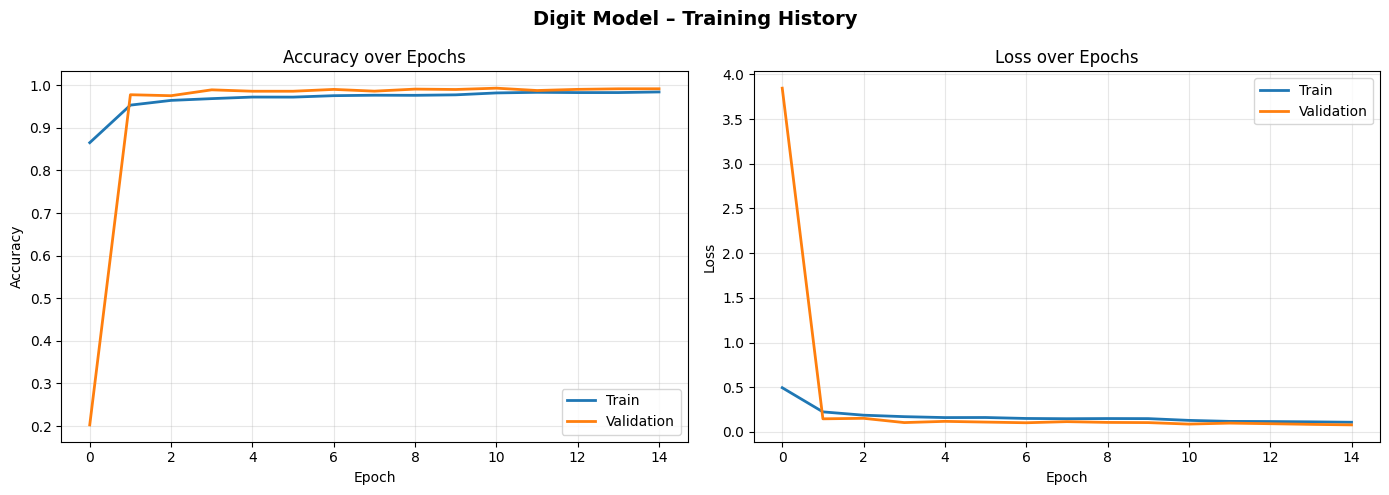

   Plot saved to plots/digit_training.png


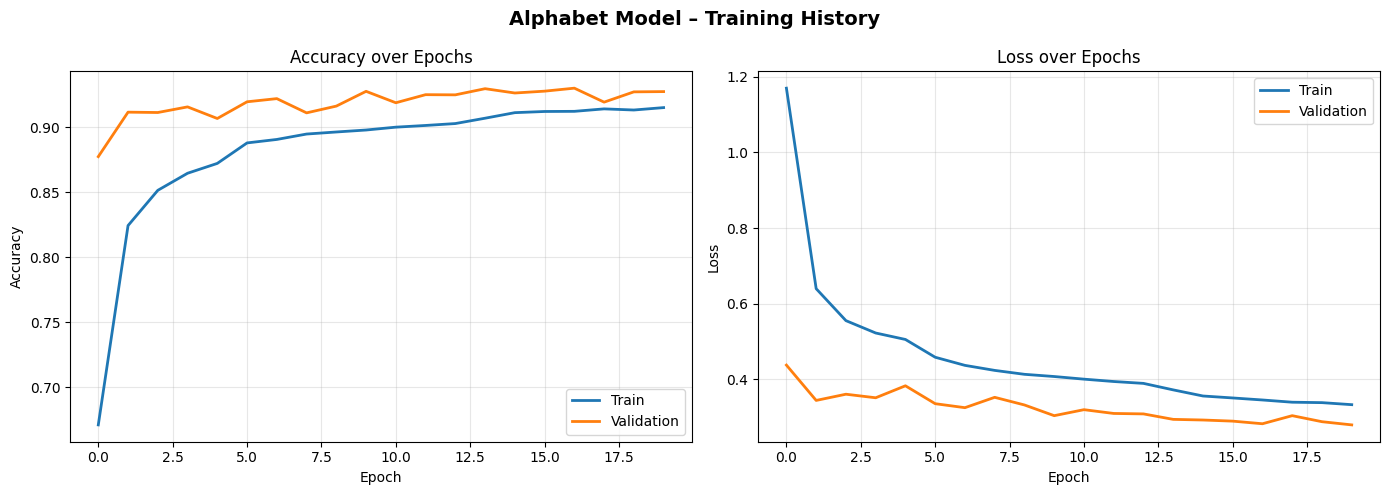

   Plot saved to plots/alphabet_training.png
✅ Training plots done!


In [ ]:
def plot_history(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train',      linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train',      linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'   Plot saved to {save_path}')


plot_history(digit_history, 'Digit Model – Training History',
             'plots/digit_training.png')

plot_history(alpha_history, 'Alphabet Model – Training History',
             'plots/alphabet_training.png')

print('✅ Training plots done!')

## 📊 Step 10 — Evaluate: Metrics + Confusion Matrix


  Digit CNN — Evaluation Results
  Accuracy  : 99.33%
  Precision : 99.33%
  Recall    : 99.33%
  F1 Score  : 99.33%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



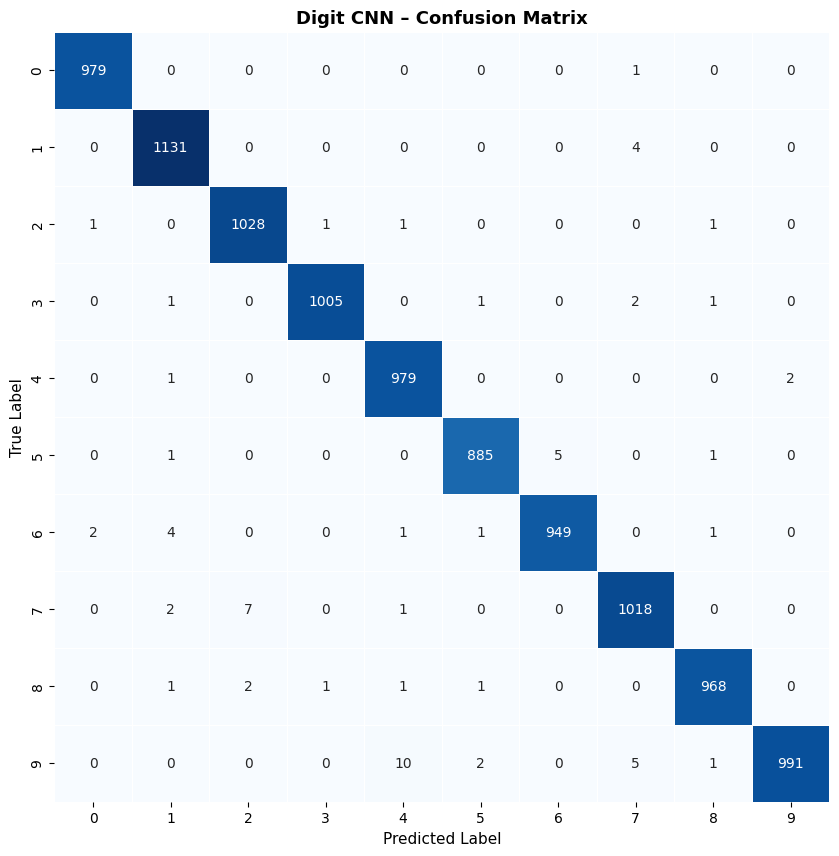

   Confusion matrix saved to plots/digit_cnn_confusion.png

  Alphabet CNN — Evaluation Results
  Accuracy  : 93.01%
  Precision : 93.77%
  Recall    : 93.01%
  F1 Score  : 93.32%

              precision    recall  f1-score   support

           A       0.96      0.93      0.94       800
           B       0.97      0.98      0.98       800
           C       0.99      0.92      0.95       800
           D       0.98      0.96      0.97       800
           E       0.94      0.99      0.96       800
           F       0.99      0.97      0.98       800
           G       0.93      0.82      0.87       800
           H       0.95      0.96      0.95       800
           I       0.77      0.71      0.74       800
           J       0.97      0.95      0.96       800
           K       0.99      0.98      0.98       800
           L       0.75      0.78      0.76       800
           M       0.99      1.00      0.99       800
           N       0.97      0.94      0.95       800
        

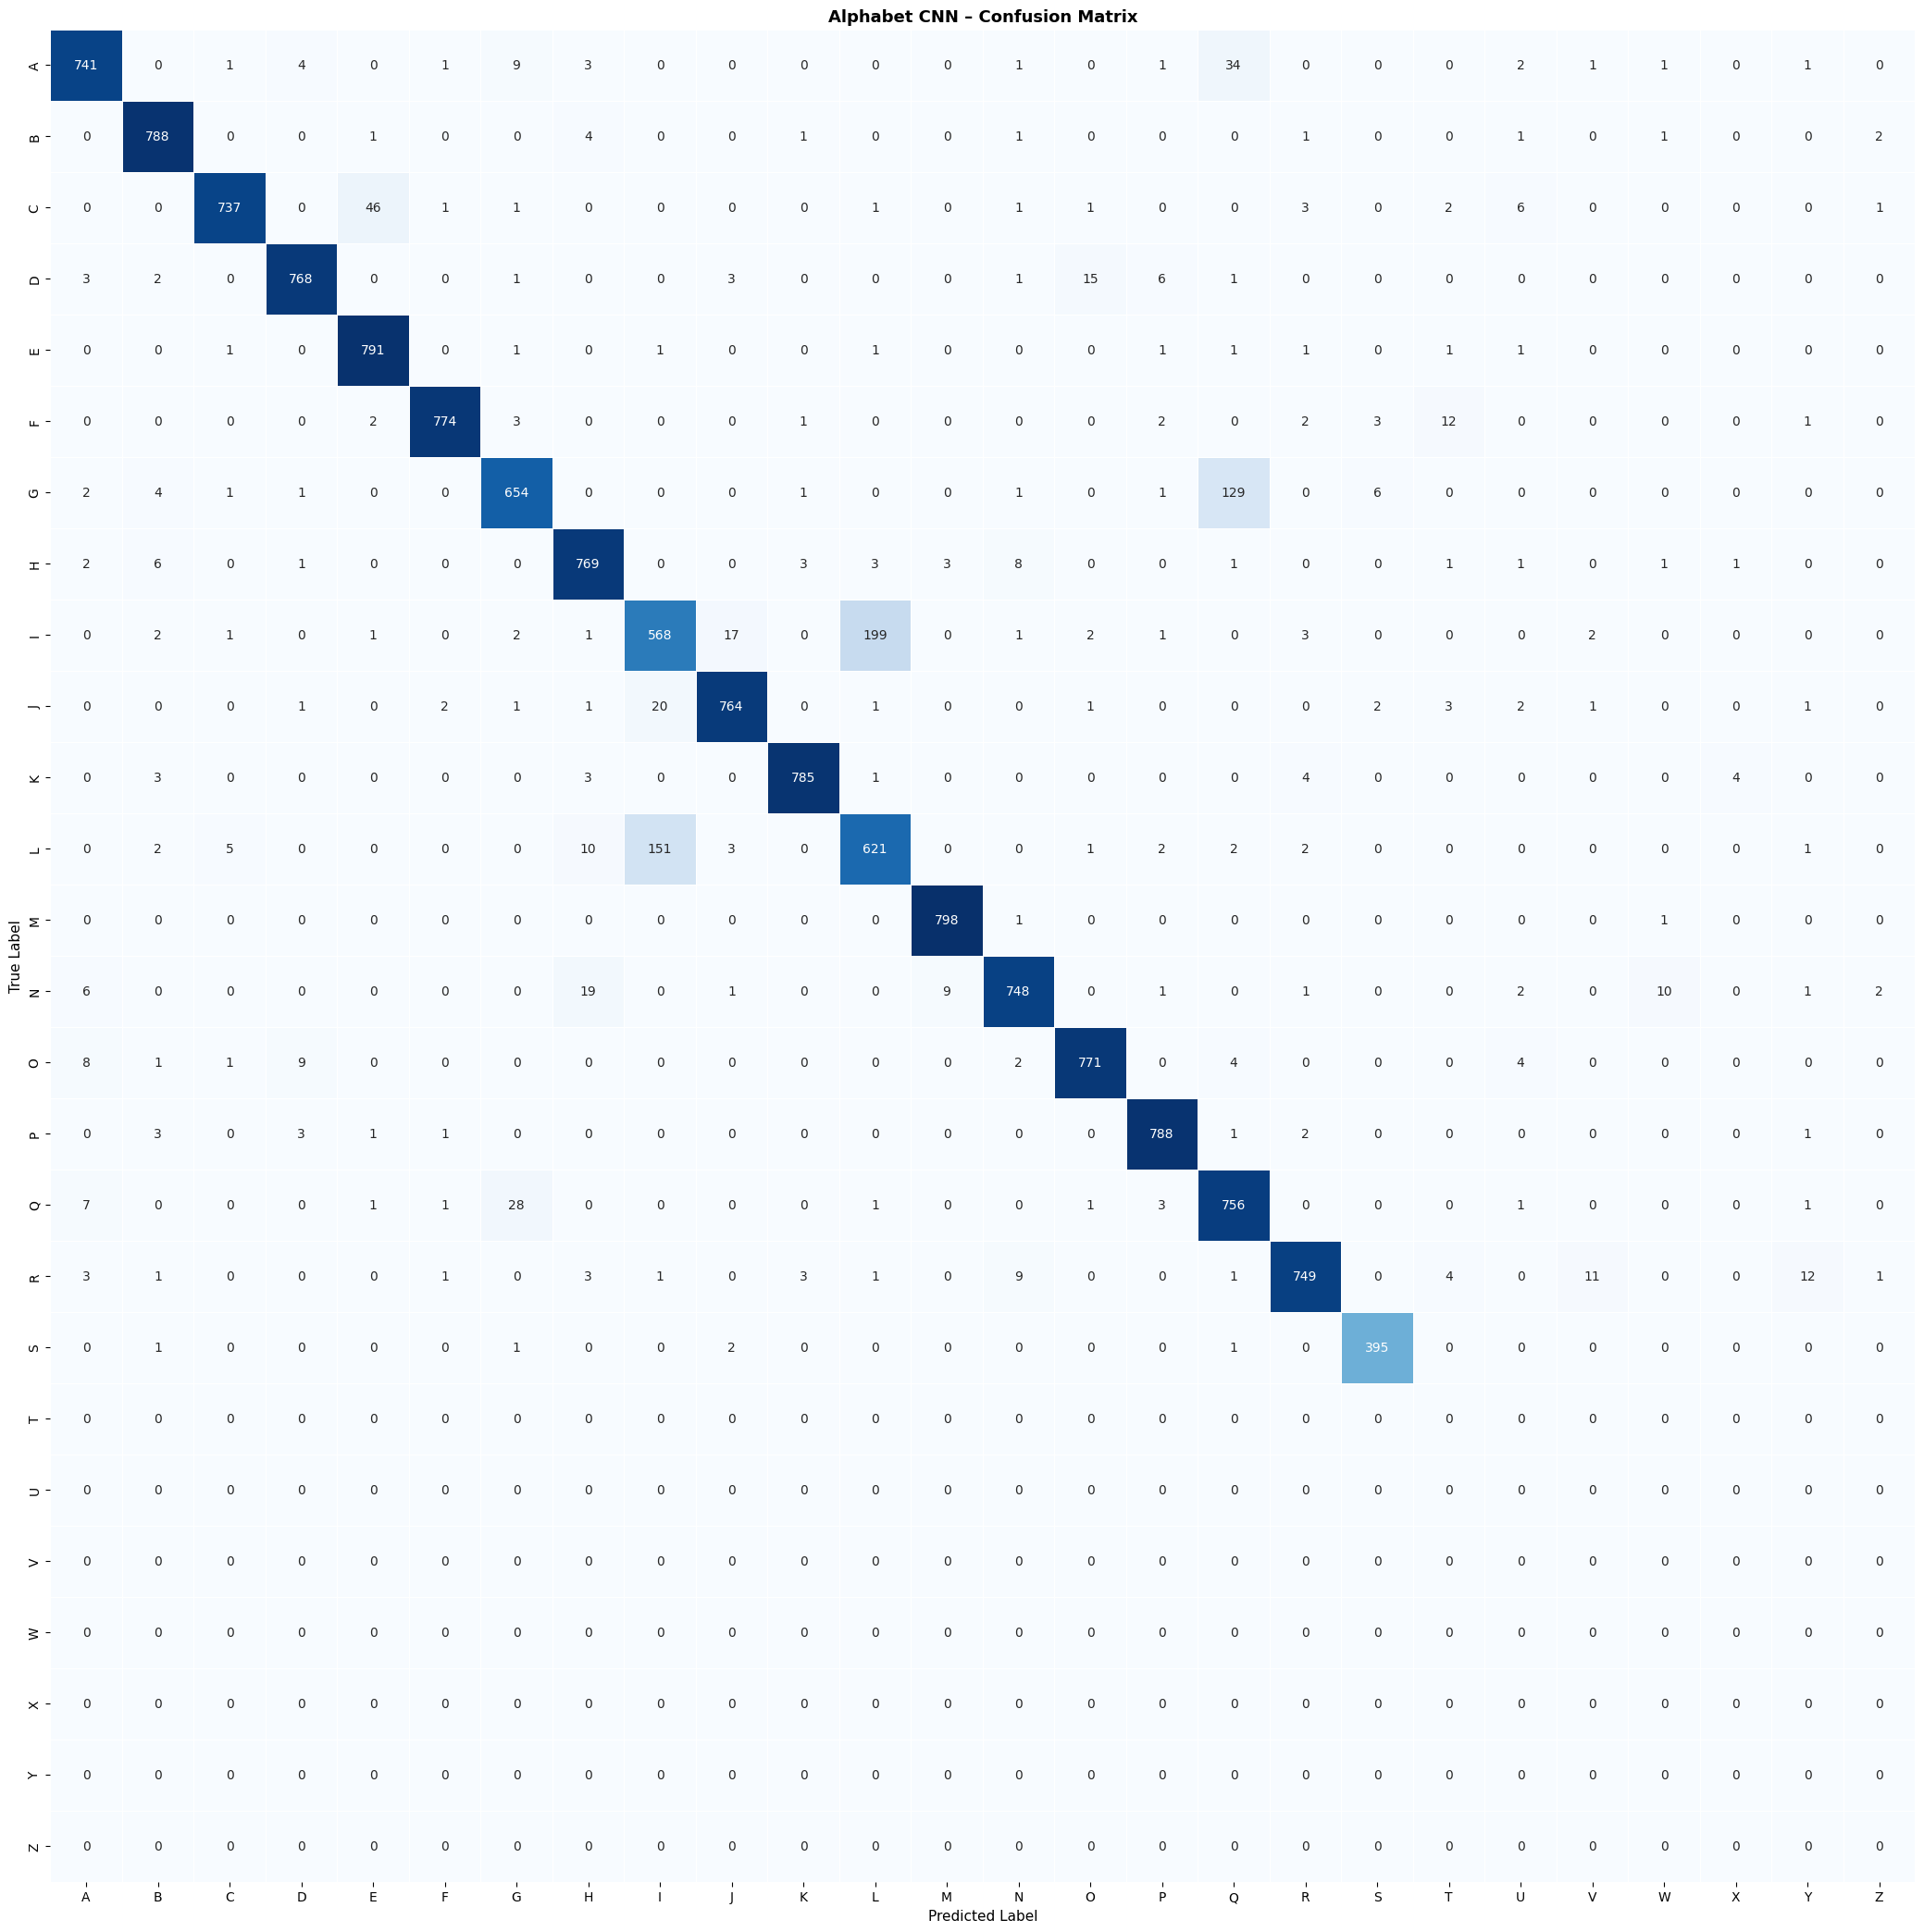

   Confusion matrix saved to plots/alphabet_cnn_confusion.png


In [ ]:
def evaluate_model(model, x_test, y_test_oh, labels, name):
    """Compute accuracy, precision, recall, F1 and plot confusion matrix."""

    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob,    axis=1)
    y_true = np.argmax(y_test_oh, axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,   y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true,       y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {name} — Evaluation Results')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1 Score  : {f1*100:.2f}%')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=labels, zero_division=0))

    # Confusion matrix
    cm       = confusion_matrix(y_true, y_pred)
    fig_size = max(10, len(labels))
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.4, cbar=False)
    plt.title(f'{name} – Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label',      fontsize=11)
    safe = name.replace(' ', '_').lower()
    plt.savefig(f'plots/{safe}_confusion.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'   Confusion matrix saved to plots/{safe}_confusion.png')


evaluate_model(digit_model, x_test_d, y_test_d, DIGIT_LABELS,    'Digit CNN')
evaluate_model(alpha_model, x_test_a, y_test_a, ALPHABET_LABELS, 'Alphabet CNN')

## 🔮 Step 11 — Predictions on Sample Test Images

/tmp/ipykernel_3530/3621898509.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3530/3621898509.py:27: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


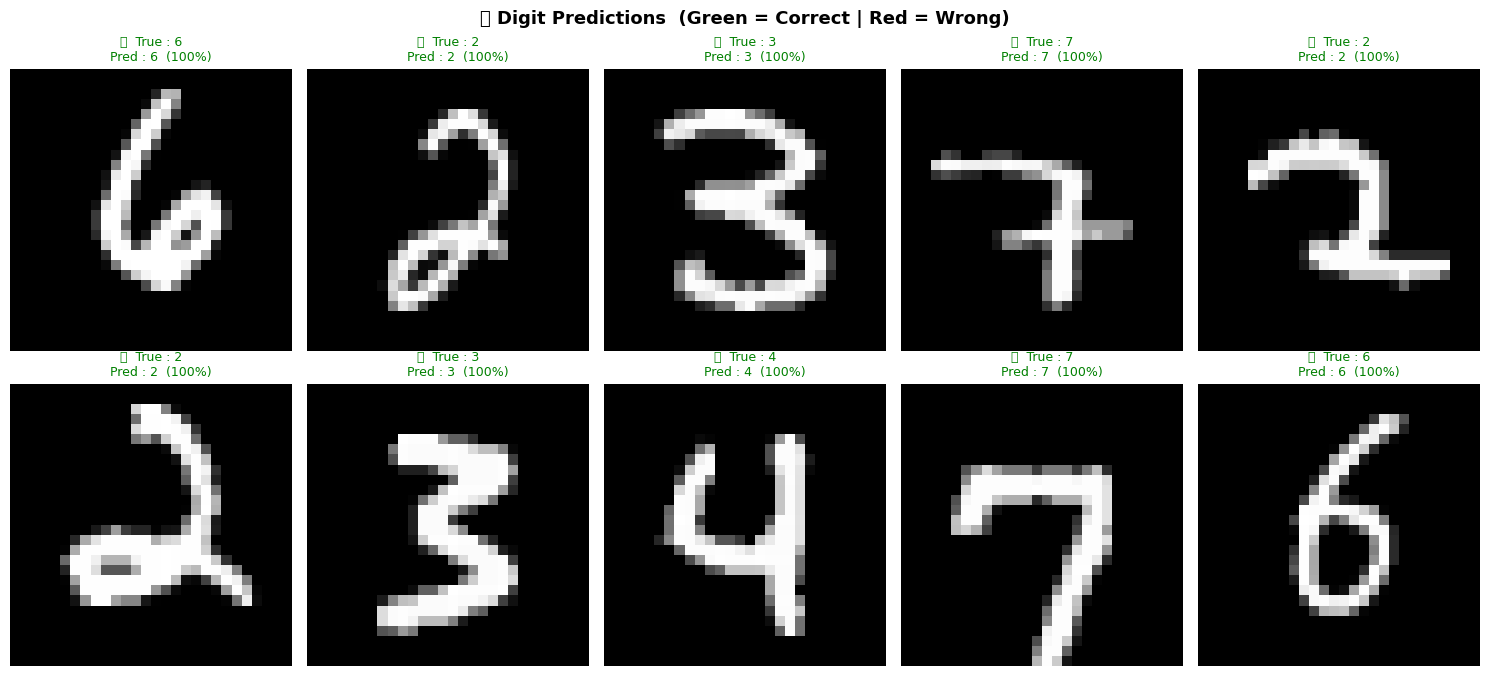

/tmp/ipykernel_3530/3621898509.py:27: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


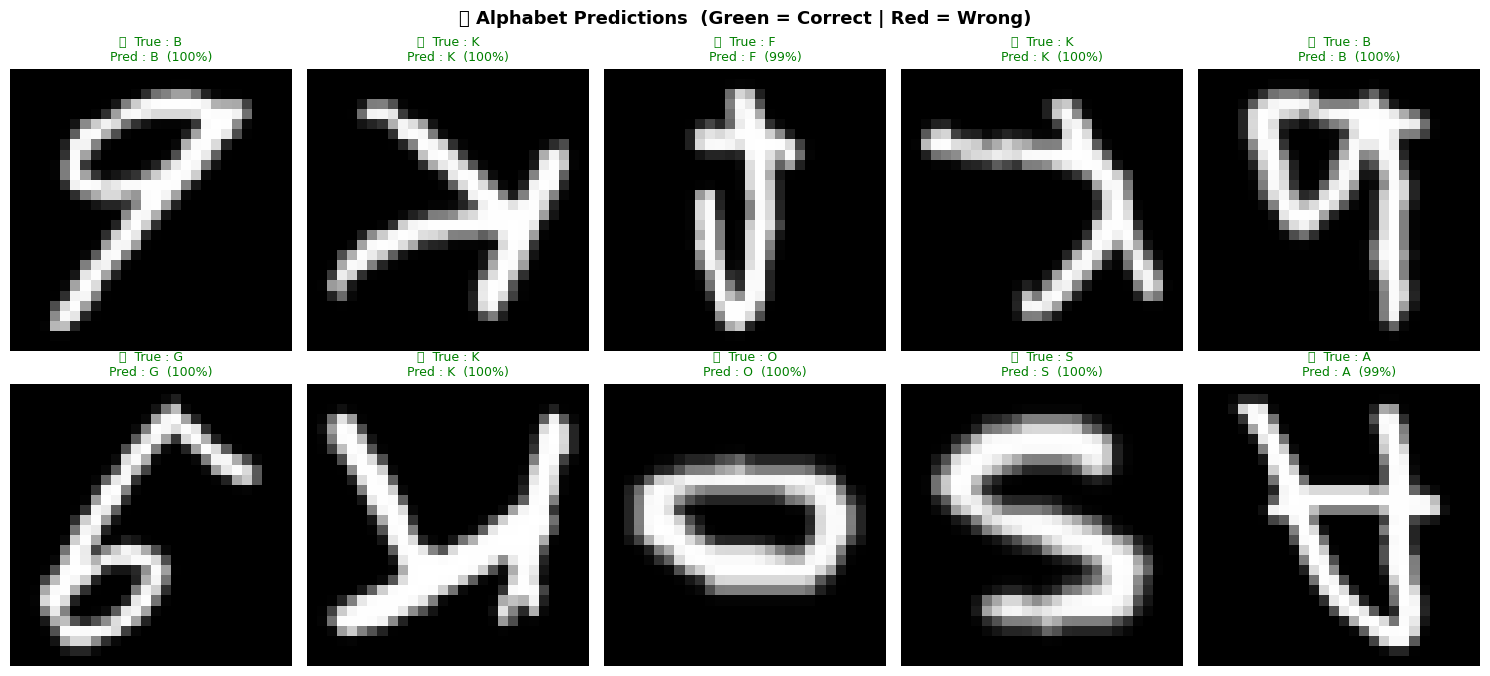

In [ ]:
def predict_and_show(model, x_test, y_test_oh, labels, title, n=10):
    """Show n random test images with true vs predicted labels."""
    np.random.seed(42)
    indices = np.random.choice(len(x_test), n, replace=False)
    images  = x_test[indices]
    y_true  = np.argmax(y_test_oh[indices], axis=1)
    y_prob  = model.predict(images, verbose=0)
    y_pred  = np.argmax(y_prob, axis=1)
    confs   = np.max(y_prob,   axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        correct = (y_pred[i] == y_true[i])
        color   = 'green' if correct else 'red'
        icon    = '✅' if correct else '❌'
        axes[i].set_title(
            f'{icon}  True : {labels[y_true[i]]}\n'
            f'     Pred : {labels[y_pred[i]]}  ({confs[i]*100:.0f}%)',
            color=color, fontsize=9
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


predict_and_show(digit_model, x_test_d, y_test_d, DIGIT_LABELS,
                 '🔢 Digit Predictions  (Green = Correct | Red = Wrong)')

predict_and_show(alpha_model, x_test_a, y_test_a, ALPHABET_LABELS,
                 '🔤 Alphabet Predictions  (Green = Correct | Red = Wrong)')

## 💾 Step 12 — Download Trained Models to Your Laptop

In [ ]:
from google.colab import files

print('📥 Downloading digit_model.keras ...')
files.download('saved_models/digit_model.keras')

print('📥 Downloading alphabet_model.keras ...')
files.download('saved_models/alphabet_model.keras')

print()
print('✅ Both models downloaded!')
print()
print('Next steps on your laptop:')
print('  1. Place both .keras files inside  saved_models/')
print('  2. Run:  python app.py')

📥 Downloading digit_model.keras ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading alphabet_model.keras ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Both models downloaded!

Next steps on your laptop:
  1. Place both .keras files inside  saved_models/
  2. Run:  python app.py


## 🖼️ Step 13 — (Optional) Upload & Predict Your Own Image

Upload a handwritten character image (PNG or JPG):


Saving Screenshot 2026-03-19 182435.png to Screenshot 2026-03-19 182435.png


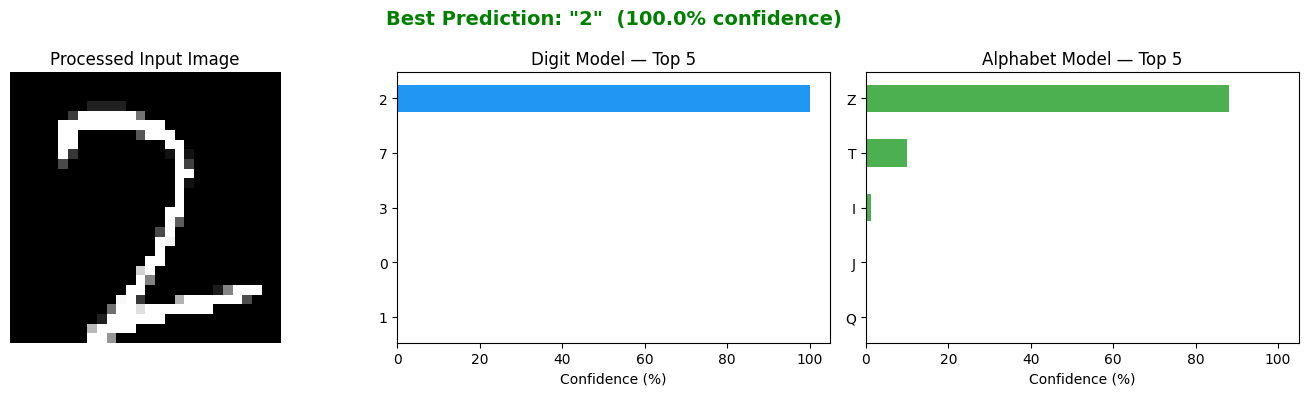

In [ ]:
import cv2
from google.colab import files as colab_files

print('Upload a handwritten character image (PNG or JPG):')
uploaded = colab_files.upload()

for filename, data in uploaded.items():
    # Decode image
    img = cv2.imdecode(
        np.frombuffer(data, np.uint8),
        cv2.IMREAD_GRAYSCALE
    )

    # Preprocess
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)                          # invert white background
    img = cv2.GaussianBlur(img, (3, 3), 0)                  # remove noise
    _, img = cv2.threshold(img, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # binarize
    img = cv2.resize(img, (28, 28))
    inp = img.astype('float32') / 255.0
    inp = inp.reshape(1, 28, 28, 1)

    # Predict with both models
    d_prob = digit_model.predict(inp, verbose=0)[0]
    a_prob = alpha_model.predict(inp, verbose=0)[0]

    d_label = DIGIT_LABELS[np.argmax(d_prob)]
    d_conf  = float(np.max(d_prob))
    a_label = ALPHABET_LABELS[np.argmax(a_prob)]
    a_conf  = float(np.max(a_prob))

    best_label = d_label if d_conf >= a_conf else a_label
    best_conf  = max(d_conf, a_conf)

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        f'Best Prediction: "{best_label}"  ({best_conf*100:.1f}% confidence)',
        fontsize=14, fontweight='bold', color='green'
    )

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Processed Input Image')
    axes[0].axis('off')

    top5_d = sorted(zip(DIGIT_LABELS,    d_prob), key=lambda x: -x[1])[:5]
    axes[1].barh([x[0] for x in top5_d][::-1],
                  [x[1]*100 for x in top5_d][::-1],
                  color='#2196F3', height=0.5)
    axes[1].set_title('Digit Model — Top 5')
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim(0, 105)

    top5_a = sorted(zip(ALPHABET_LABELS, a_prob), key=lambda x: -x[1])[:5]
    axes[2].barh([x[0] for x in top5_a][::-1],
                  [x[1]*100 for x in top5_a][::-1],
                  color='#4CAF50', height=0.5)
    axes[2].set_title('Alphabet Model — Top 5')
    axes[2].set_xlabel('Confidence (%)')
    axes[2].set_xlim(0, 105)

    plt.tight_layout()
    plt.show()